# Introduction

This notebook is intended to analyze the cleaned precipitation data of the cities of Seattle, Washington and Hilo, Hawaii.

We are trying to determine which city is "rainier" by looking at which city experiences more days where it actually rains, and which city experiences more precipitation overall.

The original Seattle and Hilo data was sourced from NOAA:

https://www.ncei.noaa.gov/cdo-web/search?datasetid=GHCND

The process by which the data was cleaned, as well as the cleaned data can be found in my github repo:

https://github.com/ayoung42/5100-weather-project/upload/main/code/Seattle_Hilo_Weather.ipynb



## Import libraries

In [2]:
# Import pandas, numpy, matplotlib, and seaborns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# set the plotting style
sns.set_style("whitegrid")

## Load the data

In [3]:
df= pd.read_csv("clean_seattle_hilo_weather.csv")

In [4]:
df.head()

,date,city,precipitation,day_of_year
0,2018-01-01,HILO,0.00,1
1,2018-01-02,HILO,0.00,2
2,2018-01-03,HILO,0.01,3
3,2018-01-04,HILO,0.00,4
4,2018-01-05,HILO,0.00,5


## Explore the data by creating a line plot of precipitation over time for each city and looking at a numerical summary

#### Hilo seems to have the same or more days of rain than Seattle, as well as more precipitation on the days with rain

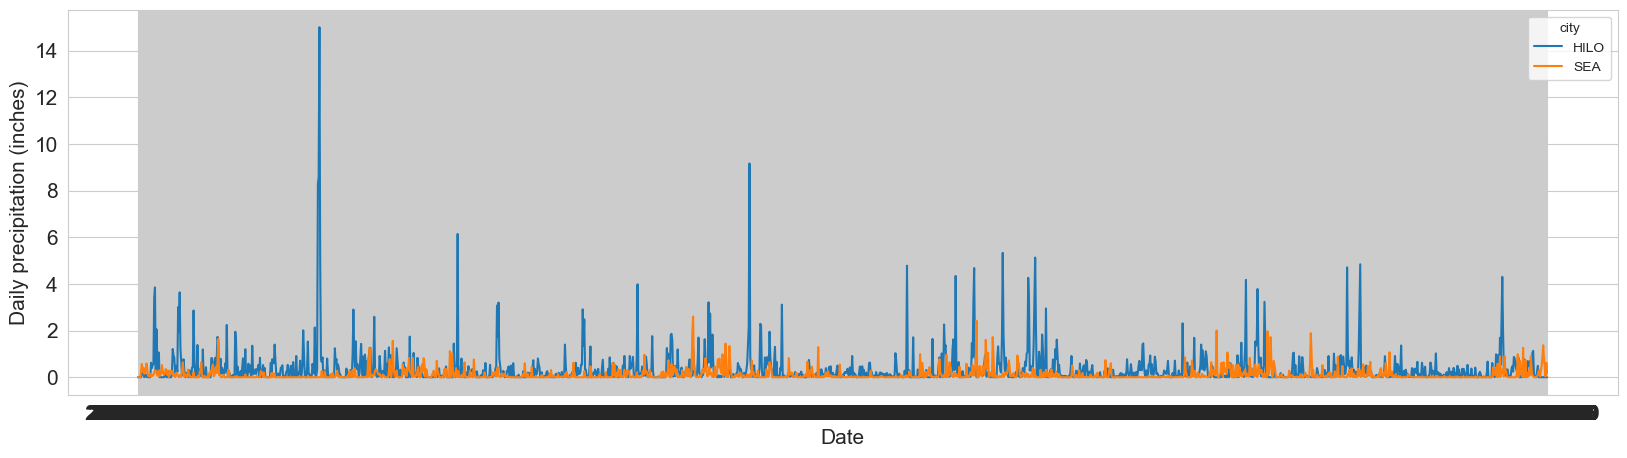

In [5]:
plt.figure(figsize=(20,5))

sns.lineplot(data=df, x='date', y = 'precipitation', hue = 'city')

plt.xlabel('Date', fontsize=15)
plt.ylabel('Daily precipitation (inches)', fontsize =15)

plt.tick_params(labelsize =15)

plt.show()

#### Compute numerical summaries for precipitation in each city
From this graph we can see that the average rainfall from 2018-2022 in Hilo (0.35in) is almost three times as much as rain in Seattle (0.24).
Most surprising to me is the stadard deviation of the two cities with Hilo being almost 80% and Seattle 25%. To me this indicates that the deviation from the average is higher in Hilo than in Seattle. So while it rains in Seattle, it's more or less the same quantity of rain, meanwhile the amount of rain varies more wildly in Hilo. This is supported by the max column where Hilo received 15 inches of rain in one day, as compared to Seattle's max of 2.6

In [6]:
df[['city', 'precipitation']].groupby('city').describe()

precipitation                                                 
             count      mean       std  min   25%   50%   75%   max
city                                                               
HILO        1826.0  0.345416  0.782260  0.0  0.01  0.11  0.36  15.0
SEA         1826.0  0.113270  0.240516  0.0  0.00  0.01  0.12   2.6

# Analysis

What do we mean by "rainier"?
To my mind there are a few ways we could describe this quatitatively:
- Maximum amount of rain in a given day
- Higher overall volume of rainfall in a given timeframe
- Higher average amount of rain in a given timeframe
- More days of rain across a given timeframe (2018-2022 in our case), and fewer days with 0 rain

## Maximum Amount of Rain in a Day

In [7]:
df[['city', 'precipitation']].groupby('city').max()

,precipitation
city,
HILO,15.0
SEA,2.6


## Volume of Rain Every Year

#### Add a "Year" column to the dataframe

In [8]:
df['year']= pd.DatetimeIndex(df['date']).year
df.head()

,date,city,precipitation,day_of_year,year
0,2018-01-01,HILO,0.00,1,2018
1,2018-01-02,HILO,0.00,2,2018
2,2018-01-03,HILO,0.01,3,2018
3,2018-01-04,HILO,0.00,4,2018
4,2018-01-05,HILO,0.00,5,2018


In [9]:
# sums across years
yearly_rain= df[['year','precipitation','city']].groupby(['city', 'year']).sum()
yearly_rain

precipitation
city year               
HILO 2018     176.440000
     2019     100.820000
     2020     121.460000
     2021     137.970000
     2022      94.040000
SEA  2018      37.244167
     2019      38.653333
     2020      43.221667
     2021      44.434167
     2022      43.278333

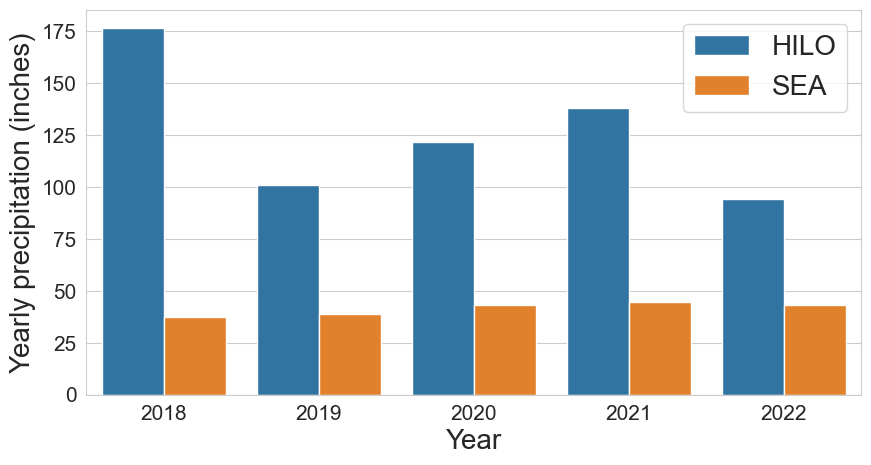

In [17]:
plt.figure(figsize=(10,5))

sns.barplot(data=yearly_rain, x='year', y = 'precipitation', hue = 'city')

plt.xlabel('Year', fontsize=20)
plt.ylabel('Yearly precipitation (inches)', fontsize =20)

plt.legend(fontsize=20) 
plt.tick_params(labelsize =15)

plt.show()

Hilo receives more cumulative rainfall every year than Seattle does from 2018-2022. Seattle seems to receive a consistent amount of rain (around 35-45 inches of rain) whereas Hilo has a larger spread with 94-176 inches of rain in a year.

## Different Ways to Examine Average Rainfall

In [10]:
df[['city', 'precipitation']].groupby('city').mean()

,precipitation
city,
HILO,0.345416
SEA,0.113270


### Create a bar plot of mean daily precipitation for each city 

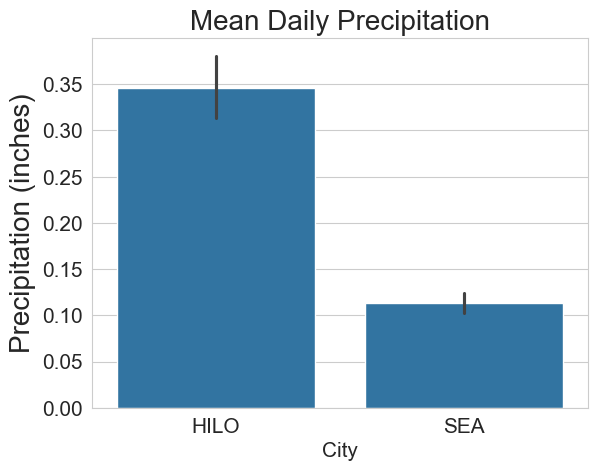

In [19]:
sns.barplot(data=df, x = 'city', y = 'precipitation')

plt.xlabel('City', fontsize=15)
plt.ylabel('Precipitation (inches)', fontsize=20)
plt.title('Mean Daily Precipitation', fontsize=20)

plt.tick_params(labelsize=15)

plt.show()

###  Add a new column to the data frame with the number of the month

In [20]:
df['month']= pd.DatetimeIndex(df['date']).month
df.head()

,date,city,precipitation,day_of_year,year,month
0,2018-01-01,HILO,0.00,1,2018,1
1,2018-01-02,HILO,0.00,2,2018,1
2,2018-01-03,HILO,0.01,3,2018,1
3,2018-01-04,HILO,0.00,4,2018,1
4,2018-01-05,HILO,0.00,5,2018,1


In [21]:
df['month'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32)

### Compare the mean precipitation averaged over all days

### Plot the distribution of precipitation by month for each city using boxplots

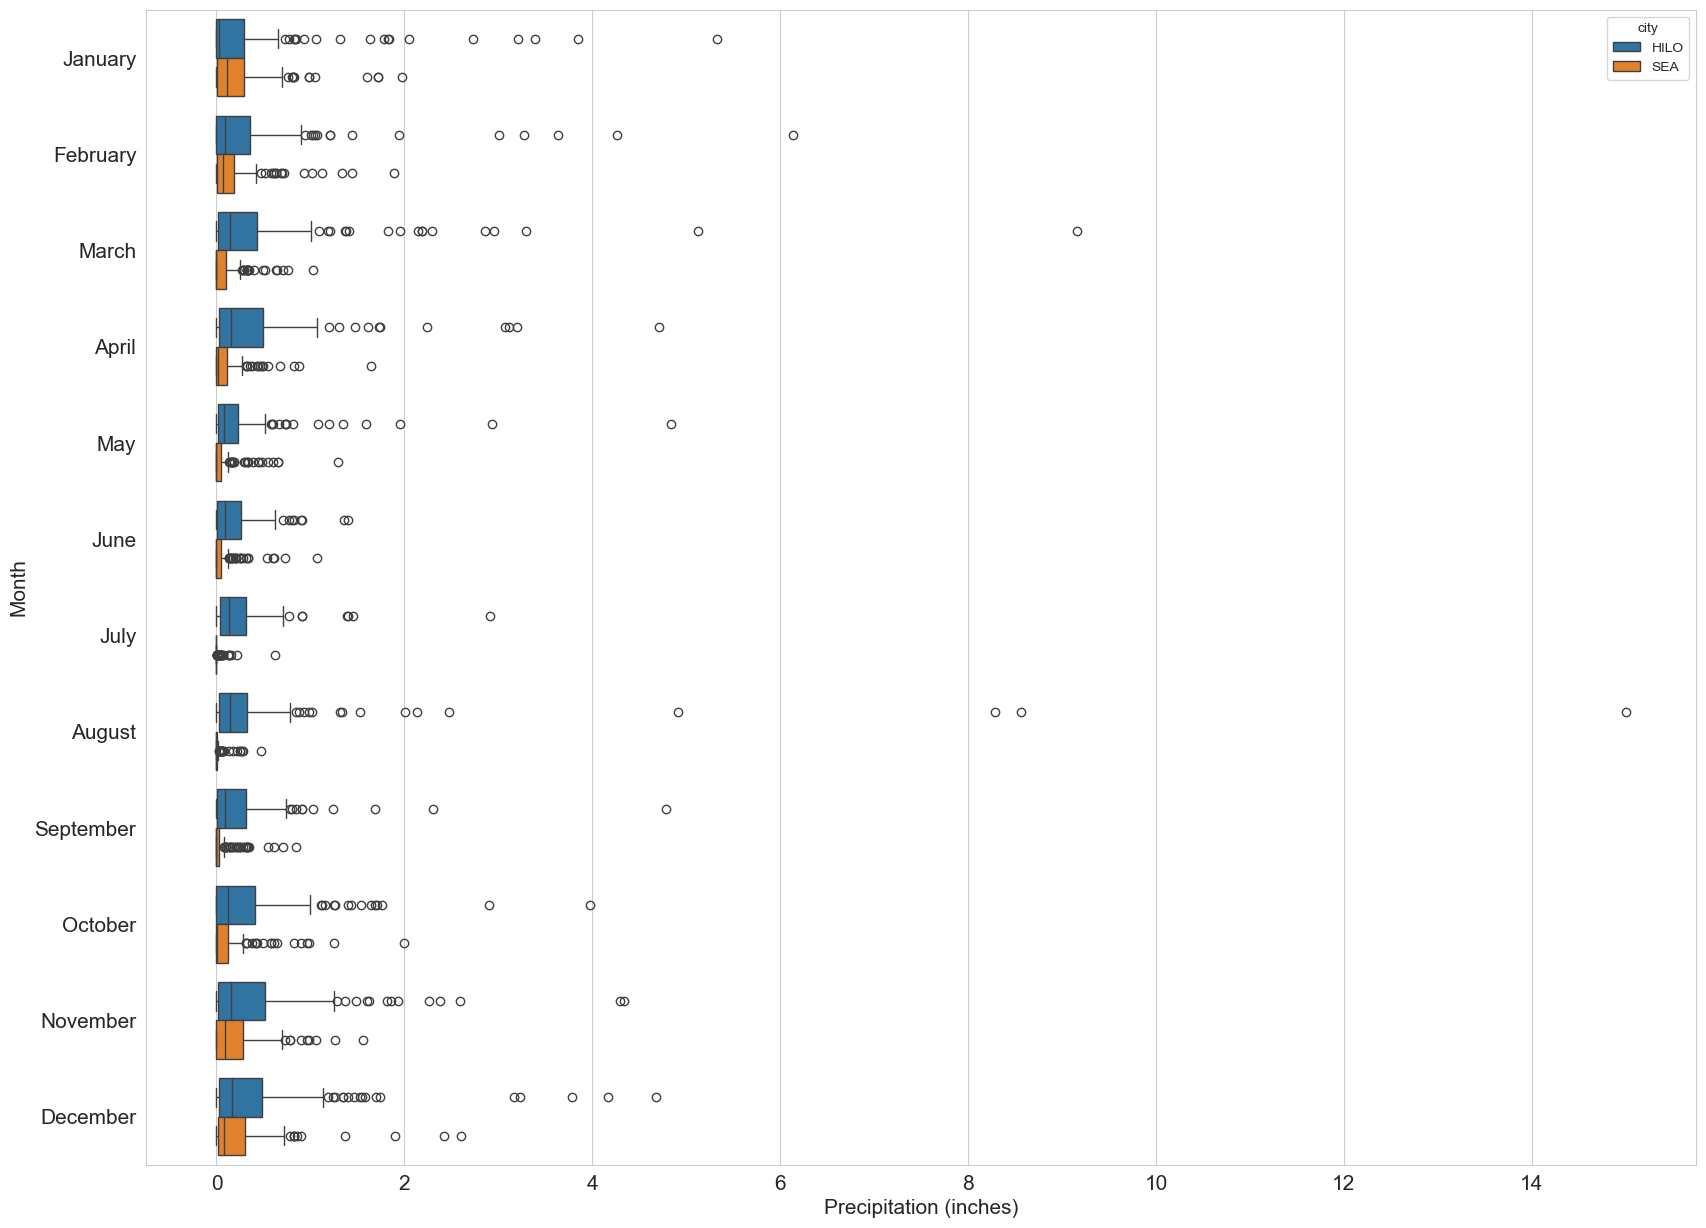

In [35]:
plt.figure(figsize=(20,15))

sns.boxplot(data=df, x='precipitation', y = 'month', hue = 'city', orient='h')

plt.ylabel('Month', fontsize=15)
plt.xlabel('Precipitation (inches)', fontsize =15)

plt.tick_params(labelsize =15)

#get month names and set as xaxis tick labels
import calendar
month_names = list(calendar.month_name[1:]) #month names
plt.yticks(ticks=range(12),labels=month_names) #sets yaxis ticks to month names

plt.show()

##### Zooming in
Here we can see that Hilo is consistently receiving more rainfall (except in January when Hilo and Seattle are even), with fewer days of 0 rainfall, higher 75% lines and higher max lines 

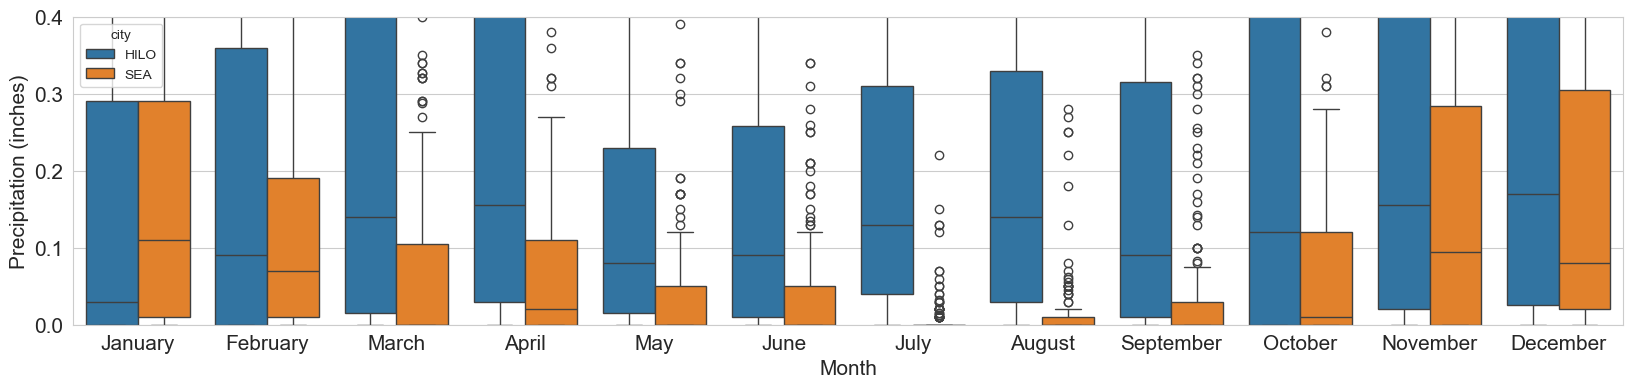

In [37]:
plt.figure(figsize=(20,4))

sns.boxplot(data=df, x='month', y = 'precipitation', hue = 'city')

plt.xlabel('Month', fontsize=15)
plt.ylabel('Precipitation (inches)', fontsize =15)

plt.tick_params(labelsize =15)

plt.xticks(ticks=range(12),labels=month_names)

plt.ylim(0, 0.4)

plt.show()

In [38]:
df[['month','precipitation','city']].groupby(['city', 'month']).mean()

precipitation
city month               
HILO 1           0.325484
     2           0.369291
     3           0.470000
     4           0.392000
     5           0.238129
     6           0.181133
     7           0.235935
     8           0.485935
     9           0.242867
     10          0.343613
     11          0.419000
     12          0.439032
SEA  1           0.230742
     2           0.176472
     3           0.089075
     4           0.100483
     5           0.069161
     6           0.063167
     7           0.013984
     8           0.019995
     9           0.055622
     10          0.118452
     11          0.201867
     12          0.224903

## Plot the proportion of days with any precipitation

#### Add a variable to the dataframe that indicated where there was any precipitation

In [83]:
df['any_precipitation'] = df['precipitation'] > 0

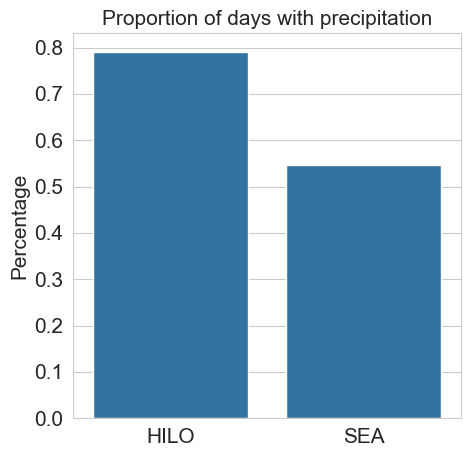

In [81]:
plt.figure(figsize=(5,5))

sns.barplot(data=df, x='city', y = 'any_precipitation', errorbar=None)

plt.xlabel('', fontsize=15)
plt.ylabel('Percentage', fontsize =15)
plt.title('Proportion of days with precipitation', fontsize=15)

plt.tick_params(labelsize =15)

plt.show()

From this barplot we can see that almost 80% of days in Hilo have recorded rain as compared to Seattle's over 50%

#### Lets examine the proportion of days with rain per month

From this plot we can see a definite overall rainy trend in Hilo where very few months have no recorded rain. Seattle has definite cycles with less than half of days receiving rain from June till September 

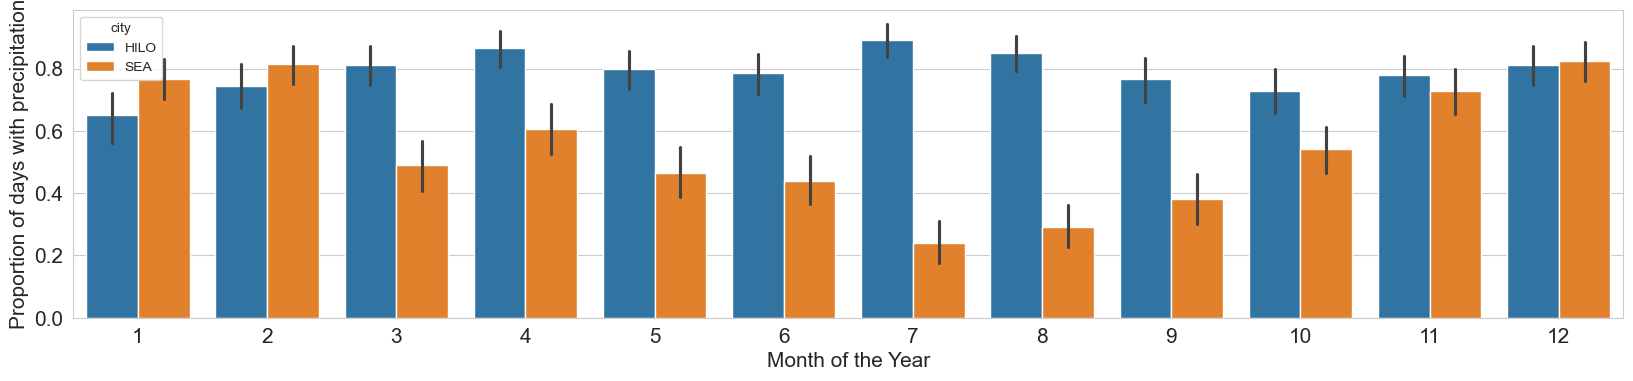

In [46]:
plt.figure(figsize=(20,4))

sns.barplot(data=df, x='month', y = 'any_precipitation', hue = 'city')

plt.xlabel('Month of the Year', fontsize=15)
plt.ylabel('Proportion of days with precipitation', fontsize =15)

plt.tick_params(labelsize =15)

plt.show()

In [47]:
from scipy import stats

In [59]:
significance_level = 0.05
significantly_different = np.zeros(12)

for month in range(1, 13):

    sea_data = df.loc[(df['city'] == 'SEA') & (df['month']== month), 'precipitation']
    hilo_data = df.loc[(df['city'] == 'HILO') & (df['month']== month), 'precipitation']

    t_statistic, p_value = stats.ttest_ind(sea_data, hilo_data, equal_var=False)

    if p_value < significance_level:
        significantly_different[month-1]= 1
    print(f"Month {month}:")
    print(f"  t-statistic = {t_statistic:.2f}")
    print(f"  p-value t test = {p_value:.3f}")
    print("-" * 20)

Month 1:
  t-statistic = -1.44
  p-value t test = 0.153
--------------------
Month 2:
  t-statistic = -2.64
  p-value t test = 0.009
--------------------
Month 3:
  t-statistic = -4.66
  p-value t test = 0.000
--------------------
Month 4:
  t-statistic = -5.14
  p-value t test = 0.000
--------------------
Month 5:
  t-statistic = -3.84
  p-value t test = 0.000
--------------------
Month 6:
  t-statistic = -4.98
  p-value t test = 0.000
--------------------
Month 7:
  t-statistic = -8.01
  p-value t test = 0.000
--------------------
Month 8:
  t-statistic = -3.65
  p-value t test = 0.000
--------------------
Month 9:
  t-statistic = -4.49
  p-value t test = 0.000
--------------------
Month 10:
  t-statistic = -4.58
  p-value t test = 0.000
--------------------
Month 11:
  t-statistic = -3.56
  p-value t test = 0.000
--------------------
Month 12:
  t-statistic = -3.17
  p-value t test = 0.002
--------------------


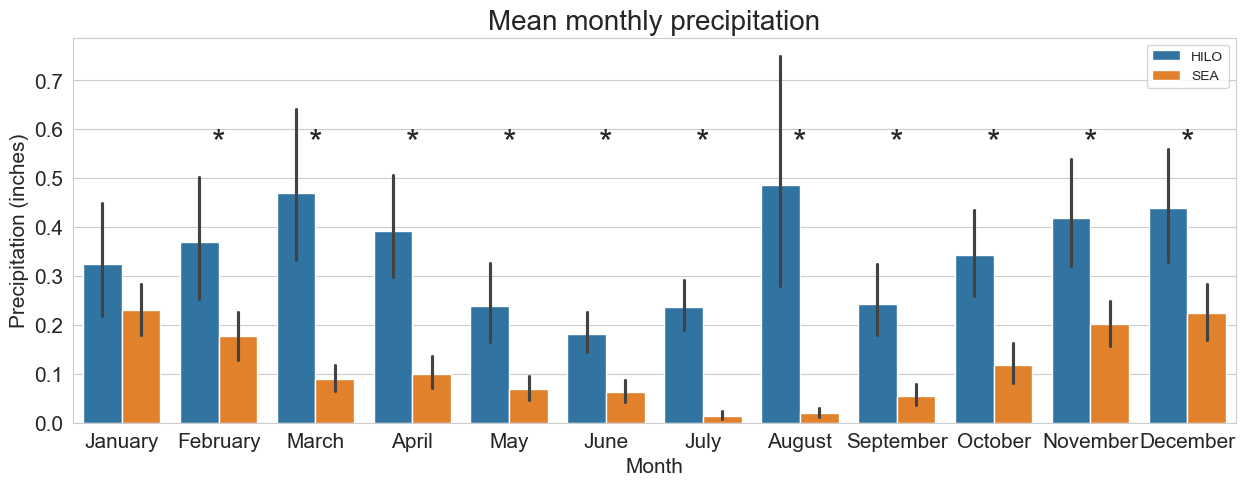

In [79]:
plt.figure(figsize=(15,5))

sns.barplot(data=df, x='month', y = 'precipitation', hue = 'city')

plt.xlabel('Month', fontsize=15)
plt.ylabel('Precipitation (inches)', fontsize =15)
plt.title('Mean monthly precipitation', fontsize=20)

plt.tick_params(labelsize =15)

plt.xticks(ticks=range(12), labels=month_names)
plt.legend(fontsize=10,loc='upper right')

# add stars for significantly different months
for month in range(12):
    if significantly_different[month] == 1:

        # adds stars
        plt.text(month, 0.55, '*', ha='center', fontsize=25)

plt.show()

Indeed, this chart shows that in every month except January, Hilo receives statistically signicant more rainfall than Seattle.

# Conclusion

Going in, I admit, I did not know much about the weather of Hilo, I just reasoned that the more eastern islands in the Hawiian chain are wetter than the more western ones, and the genral preception of Hawaii is that it is very tropical. I was *NOT* expecting Hilo to so overwhelmingly experience more rain than Seattle. 

By our metrics:

- Maximum amount of rain in a given day: Winner Hilo
- Higher overall volume of rainfall in a given timeframe: Winner Hilo
- Higher average amount of rain in a given timeframe: Winner Hilo
- More days of rain across a given timeframe (2018-2022 in our case), and fewer days with 0 rain: Winner Hilo


Upon completing this notebook I found a Hawaiian language dictionary where the entry for rain shares an idiom: ʻeleʻele Hilo, panopano i ka ua, Hilo is black, dark with rain

Source: https://wehewehe.org/gsdl2.85/cgi-bin/hdict?d=D214647&l=en&e=d-11000-00---off-0hdict--00-1----0-10-0---0---0direct-10-ED--4--textpukuielbert%2Ctextmamaka-----0-1l--11-en-Zz-1---Zz-1-home-rain--00-3-1-00-0--4----0-0-11-00-0utfZz-8-00